<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Lab: Simple Linear Regression with Sacramento Real Estate Data

---

In this lab you will hone your exploratory data analysis (EDA) skills and practice constructing linear regressions on a data set of Sacramento real estate sales.  The data set contains information on qualities of the property, location of the property, and time of sale.

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

### 1. Read in the Sacramento housing data set.

The file is stored in the `data` subfolder.

In [15]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')

### 2. Conduct exploratory data analysis on this data set. 

If you discover any issues with the data, fix them to the best of your ability. Report any notable findings.

__Note:__
- Assign the correct data type to each column.
- Look for missing values and determine how to handle them. Keep in mind that most machine learning models cannot process null values.
- Check the value ranges for numerical and categorical columns to identify any anomalies.
- Examine the distribution of values and investigate potential outliers.

In [16]:
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


In [17]:
housing.dtypes

street           str
city             str
zip            int64
state            str
beds           int64
baths          int64
sq__ft         int64
type             str
sale_date        str
price          int64
latitude     float64
longitude    float64
dtype: object

In [18]:
housing.columns

Index(['street', 'city', 'zip', 'state', 'beds', 'baths', 'sq__ft', 'type',
       'sale_date', 'price', 'latitude', 'longitude'],
      dtype='str')

In [19]:
housing['sale_date'] = pd.to_datetime(housing['sale_date'], format="%a %b %d %H:%M:%S EDT %Y")

In [20]:
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [21]:
housing.describe()

,zip,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,985.000000,985.000000,985.000000,985.000000,985,985.000000,985.000000,985.000000
mean,95750.697462,2.911675,1.776650,1312.918782,2008-05-18 05:12:51.167512,233715.951269,38.445121,-121.193371
min,95603.000000,0.000000,0.000000,-984.000000,2008-05-15 00:00:00,-210944.000000,-121.503471,-121.551704
25%,95660.000000,2.000000,1.000000,950.000000,2008-05-16 00:00:00,145000.000000,38.482704,-121.446119
50%,95762.000000,3.000000,2.000000,1304.000000,2008-05-19 00:00:00,213750.000000,38.625932,-121.375799
75%,95828.000000,4.000000,2.000000,1718.000000,2008-05-20 00:00:00,300000.000000,38.695589,-121.294893
max,95864.000000,8.000000,5.000000,5822.000000,2008-05-21 00:00:00,884790.000000,39.020808,38.668433
std,85.176072,1.307932,0.895371,856.123224,NaN,139088.818896,5.103637,5.100670


In [22]:
housing = housing[(housing['sq__ft'] > 0) & (housing['price'] > 0)]

In [23]:
housing = housing.drop_duplicates()

In [24]:
housing.shape

(811, 12)

In [25]:
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768


When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

In [26]:
housing.to_csv('./data/sacramento_cleaned_dataframe.csv', index=False)

### 3. Our goal will be to predict price. List variables that you think qualify as predictors of price in an SLR model.

For each of the variables you believe should be considered, generate a plot showing the relationship between the independent and dependent variables.

In [27]:
housing.corr(numeric_only = True)

,zip,beds,baths,sq__ft,price,latitude,longitude
zip,1.000000,-0.067428,-0.100985,-0.100969,-0.220160,-0.132895,-0.562027
beds,-0.067428,1.000000,0.653071,0.696444,0.442892,-0.107596,0.051896
baths,-0.100985,0.653071,1.000000,0.723919,0.501123,-0.080866,0.105518
sq__ft,-0.100969,0.696444,0.723919,1.000000,0.693247,-0.102516,0.134526
price,-0.220160,0.442892,0.501123,0.693247,1.000000,0.058967,0.278226
latitude,-0.132895,-0.107596,-0.080866,-0.102516,0.058967,1.000000,0.345025
longitude,-0.562027,0.051896,0.105518,0.134526,0.278226,0.345025,1.000000


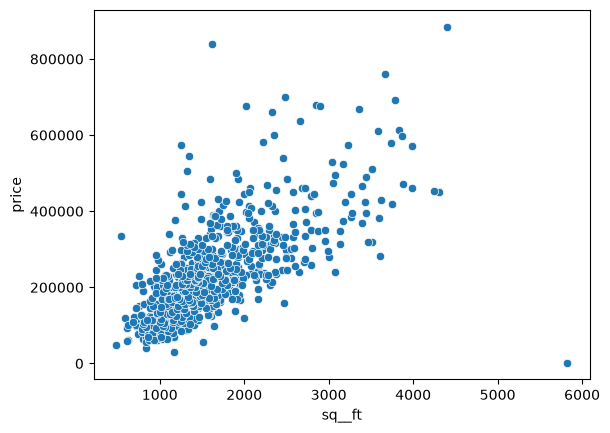

In [28]:
sns.scatterplot(data=housing, x='sq__ft',y='price')
plt.show()

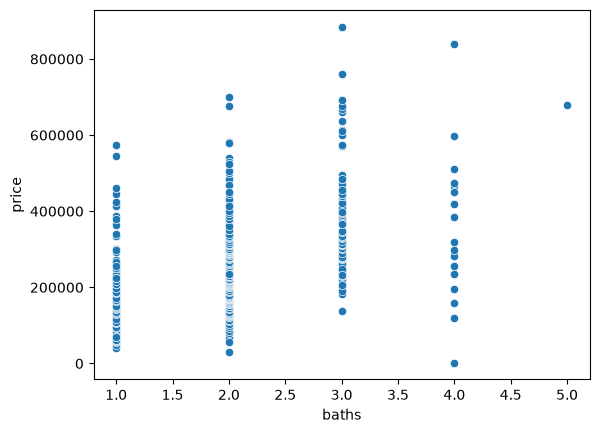

In [29]:
sns.scatterplot(data=housing, x='baths',y='price')
plt.show()

In [30]:
pd.crosstab(index=housing['baths'], columns = ['price'])

col_0,price
baths,
1,177
2,506
3,110
4,17
5,1


### 4. Which variable would be the best predictor of Y in an SLR model? Why?

Sqaure Feet, because it has the highest correlation with price 0.69. Therefore, the price can be predicted with the sqaure feet

### 5. Write a function that will take in two lists, `x` and `y`, and return the intercept and slope coefficients that minimize SSE. 

`y` is the target variable, and `x` is the predictor variable.

**Don't use `scikit-learn` for this**. Instead, use `numpy`.

The slope and intercept of simple linear regression can be calculated by using certain summary statistics. In particular, we'll need to know:

- $\bar{x}$, the mean of `x`
- $\bar{y}$, the mean of `y`
- $s_{x}$, the standard deviation of `x`
- $s_{y}$, the standard deviation of `y`
- $r_{xy}$, the correlation of `x` and `y`

Given these summary statistics, the **coefficient on `X`** (or the slope) can be given by $\beta_{1} = r_{xy} * \frac{s_{y}}{s_{x}}$. The **intercept of the model** can be given by $\beta_{0} = \bar{y} - \beta_{1}\bar{x}$.

Your function should take in `x` and `y`, then use the above summary statistics to calculate the slope and intercept.

- **Test your function on price and the variable you determined was the best predictor in Problem 4.**
- **Report the slope and intercept.**

In [31]:
def statistics(x,y):
    x = np.array(x)
    y = np.array(y)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_std = np.std(x)
    y_std = np.std(y)

    correlation = np.corrcoef(x, y)[0,1]

    coefficent = correlation * (y_std / x_std)

    intercept = y_mean - coefficent * x_mean

    return intercept, coefficent
    

### 6. Interpret the intercept and the slope.

In [32]:
x= housing['sq__ft']
y=housing['price']
statistics(x,y)

(np.float64(30352.243076665123), np.float64(125.15261406074985))

### 7. Give an example of how this model could be used for prediction and how it could be used for inference. 

**Be sure to make it clear which example is associated with prediction and which is associated with inference.**

For the prediction aspect of the model, it will estimate the price of a home based on its size (in square feet). Secondly, for the inference aspect
the model understands the relationship and impact of the columns on each other step by step. For example for the prediction, a real estate agent finds
a house on the market with a size of 1500 sqaure feet he can plug it into the regression function to predict the sale price to get an accurate estimate
for the price. For the inference example, an analyst wants to understand how the size of a property drives the price of it and by looking at the model
it can be infered that on average every square feet the house increases the value of the property increases.This helps the analyst understand the nature
direction, and magnitude fo the relationship between price and square feet.

### 8: [Bonus] Using the model you came up with in Problem 5, calculate and plot the residuals.

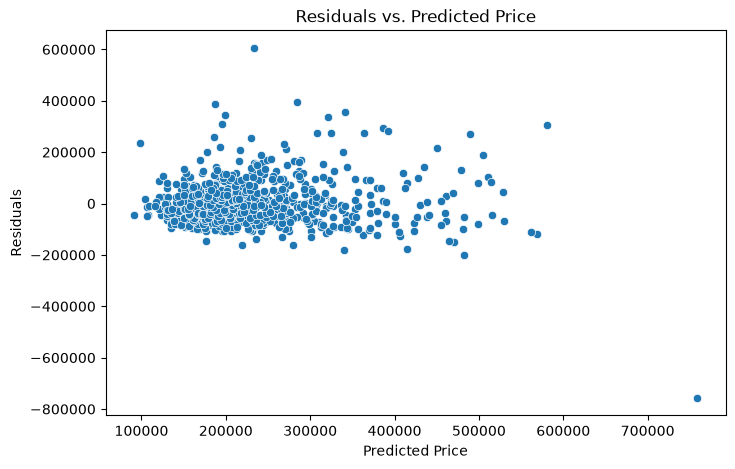

In [33]:
b0, b1 = statistics(housing['sq__ft'], housing['price'])

y_pred = b0 + b1 * housing['sq__ft']
residuals = housing['price'] - y_pred


plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Price')
plt.show()

---

## Dummy Variables

It is important to be cautious with categorical variables, which represent distict groups or categories, when building a regression. If put in a regression "as-is," categorical variables represented as integers will be treated like *continuous* variables.

That is to say, instead of group "3" having a different effect on the estimation than group "1" it will estimate literally 3 times more than group 1. 

For example, if occupation category "1" represents "analyst" and occupation category "3" represents "barista", and our target variable is salary, if we leave this as a column of integers then barista will always have `beta*3` the effect of analyst.

This will almost certainly force the beta coefficient to be something strange and incorrect. Instead, we can re-represent the categories as multiple "dummy coded" columns.



#### A Word of Caution When Creating Dummies

Let's touch on precautions we should take when dummy coding.

**If you convert a qualitative variable to dummy variables, you want to turn a variable with N categories into N-1 variables.**

> **Scenario 1:** Suppose we're working with the variable "sex" or "gender" with values "M" and "F". 

You should include in your model only one variable for "sex = F" which takes on 1 if sex is female and 0 if sex is not female! Rather than saying "a one unit change in X," the coefficient associated with "sex = F" is interpreted as the average change in Y when sex = F relative to when sex = M.

| Female | Male | 
|-------|------|
| 0 | 1 | 
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 0 |
_As we can see a 1 in the female column indicates a 0 in the male column. And so, we have two columns stating the same information in different ways._

> Scenario 2: Suppose we're modeling revenue at a bar for each of the days of the week. We have a column with strings identifying which day of the week this observation occured in.

We might include six of the days as their own variables: "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday". **But not all 7 days.**  

|Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | 
|-------|---------|-----------|----------|--------|----------|
| 1     | 0       |0          |      0   |0       | 0        | 
| 0     | 1       |0          |      0   |0       | 0        | 
| 0     | 0       |1          |      0   |0       | 0        | 
| 0     | 0       |0          |      1   |0       | 0        | 
| 0     | 0       |0          |      0   |1       | 0        | 
| 0     | 0       |0          |      0   |0       | 1        | 
| 0     | 0       |0          |      0   |0       | 0        | 

_As humans we can infer from the last row that if its is not Monday, Tuesday, Wednesday, Thursday, Friday or Saturday, it must be Sunday. Models work the same way._

The coefficient for Monday is then interpreted as the average change in revenue when "day = Monday" relative to "day = Sunday." The coefficient for Tuesday is interpreted as the average change in revenue when "day = Tuesday" relative to "day = Sunday" and so on.

The category you leave out, which the other columns are *relative to*, is often referred to as the **reference category**.

### 9. Use the `pd.get_dummies` function to convert the `type` column into dummy-coded variables.

In [34]:
housing_dummies = pd.get_dummies(housing, columns=['type'], drop_first=True)

### 10. Check the dummy columns you've created. Do they all make sense?

Use `.head()` on the new dataframe you've created. Depending on how you cleaned the data earlier in this notebook, there may be a dummy column that needs to be removed. Check that all the columns you've created make sense, and if any of the columns seem to be errors, drop them. If there don't appear to be any errors, then move on to the next step!

In [35]:
housing_dummies.head()

,street,city,zip,state,beds,baths,sq__ft,sale_date,price,latitude,longitude,type_Multi-Family,type_Residential
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,2008-05-21,59222,38.631913,-121.434879,False,True
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,2008-05-21,68212,38.478902,-121.431028,False,True
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,2008-05-21,68880,38.618305,-121.443839,False,True
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,2008-05-21,69307,38.616835,-121.439146,False,True
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,2008-05-21,81900,38.519470,-121.435768,False,True


In [36]:
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768


In [37]:
housing_dummies.columns

Index(['street', 'city', 'zip', 'state', 'beds', 'baths', 'sq__ft',
       'sale_date', 'price', 'latitude', 'longitude', 'type_Multi-Family',
       'type_Residential'],
      dtype='str')

In [38]:
housing.columns

Index(['street', 'city', 'zip', 'state', 'beds', 'baths', 'sq__ft', 'type',
       'sale_date', 'price', 'latitude', 'longitude'],
      dtype='str')

In [39]:
housing_dummies.dtypes

street                          str
city                            str
zip                           int64
state                           str
beds                          int64
baths                         int64
sq__ft                        int64
sale_date            datetime64[us]
price                         int64
latitude                    float64
longitude                   float64
type_Multi-Family              bool
type_Residential               bool
dtype: object

### 11. Build what you think may be the best MLR model predicting `price`. 

Choose at least three variables, and build a model that uses them to predict price. At least one of the variables you choose should be a dummy-coded variable. (This can be one we created before or a new one.) 

You may need to load in the scikit-learn API:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

In [40]:
X = housing_dummies[['sq__ft', 'baths', 'type_Residential', 'type_Multi-Family']]
y = housing_dummies['price']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

In [42]:
print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(['sq__ft', 'baths', 'type_Residential', 'type_Multi-Family'], model.coef_)))

Intercept: 8307.061816777743
Coefficients: {'sq__ft': np.float64(122.38841243168355), 'baths': np.float64(3106.8842010805415), 'type_Residential': np.float64(22555.040005317453), 'type_Multi-Family': np.float64(-43851.67895911015)}


### 12. Plot the true price vs the predicted price to evaluate your MLR visually.

You can use matplotlib or seaborn.

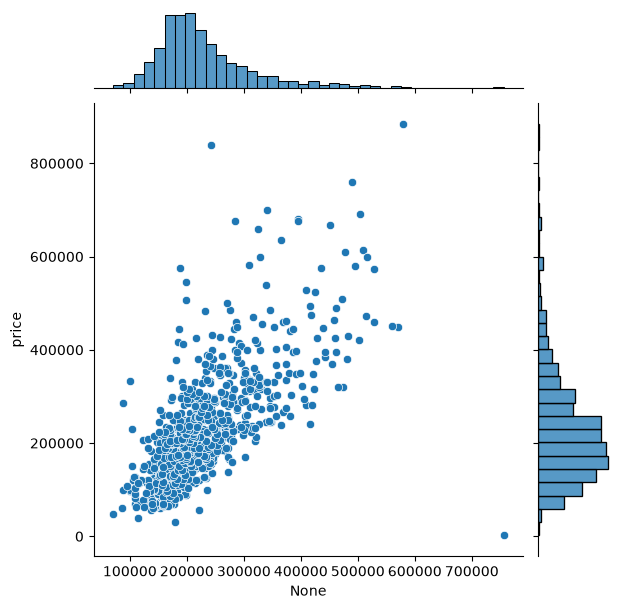

In [44]:
sns.jointplot(data = housing , x=y_pred, y=y);

### 13. List the five assumptions for an MLR model. 

Indicate which ones are the same as the assumptions for an SLR model. 

1 - linearity, both SLR & MLR

2- Indepndant errors, both SLR & MLR

3- Homoscedasticty, both SLR & MLR

4-Normality, both SLR & MLR

5-Multicollinearity, SLR model only

### 14. Pick at least two assumptions and explain whether or not you believe them to be met for your model, and explain why.

1- Linearity:

    When ploting the square feet vs the price in a scatterplot previously, there seems to be a clear upwards trend with a propontinal relationship.

2 - Homoscedasticity (constant variance):

    In the bonus problem when plotting the residual, as price increases the residual spread meaning that the error of the predicted price gets larger the high the number goes.

### 15. Regression Metrics

Implement a function called `r2_adj()` that will calculate $R^2_{adj}$ for a model.

The adjusted R-squared is calculated as $R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - k - 1} \right]$.

Unlike standard R-squared, which always increases when you add new variables, Adjusted R-squared will actually decrease if you add a useless variable to your model. This helps you find the simplest and most effective model.
- $R^2$: The standard R-squared value (coefficient of determination)
- $n$: The total number of observations (sample size)
- $k$: The number of independent variables (predictors) in your model

In [46]:
def r2_adj(X, y, r2):
    n = len(y)          
    k = X.shape[1]
    
    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
    return adjusted_r2

r2 = model.score(X, y)
print("Adjusted R2:", r2_adj(X, y, r2))

Adjusted R2: 0.4842444363610937


### 17. Metrics, metrics, everywhere...

Calculate and interpret at least three regression metrics. How well does your model perform?

In [50]:
r2 = r2_score(y,y_pred)
ae_mean=mean_absolute_error(y,y_pred)
se_mean=mean_squared_error(y,y_pred)**0.5

adj_r2 = r2_adj(X,y,r2)

print(r2)
print(adj_r2)
print(ae_mean)
print(se_mean)

0.4867913774161007
0.4842444363610937
59875.242045856845
85835.3438362166


### 18. Model Iteration

Adjust your model by adding or removing a variable. Then calculate the same regression metrics as you used in question 17. Has your model performance increased or decreased?

**Guidance:**
1. Look at the correlation between the dependent and independent variables. Which two predictors are the most correlated with each other?
2. Drop the one you think is less useful and refit the model with the remaining features.
3. Compare the new R2 and RMSE to your original model from Q11/Q17.


In [52]:
X_new = housing_dummies[['sq__ft' , 'type_Residential' , 'type_Multi-Family']]
y = housing_dummies['price']

lr_new = LinearRegression()
lr_new.fit(X_new,y)
y_pred_new = lr_new.predict(X_new)

r2_new = r2_score(y,y_pred_new)
adj_r2_new = r2_adj(X_new,y,r2_new)
ae_mean_new = mean_absolute_error(y, y_pred_new) 
se_mean_new = mean_squared_error(y, y_pred_new)**0.5

print(r2_new)
print(adj_r2_new)
print(ae_mean_new)
print(se_mean_new)

0.48665528477368325
0.4847469401074145
59824.02151166651
85846.72398837628


### 19. Add `city` as a feature

Use `OneHotEncoder` on the `city` column to add location as a feature. Since some cities only have 1-2 sales, group cities with fewer than 20 sales into `'Other'` first. Compare R2 and RMSE to the base model.

In [56]:
city_counts = housing_dummies['city'].value_counts()
group_cities = city_counts[city_counts < 20].index

housing_dummies['city_grouped'] = housing_dummies['city'].replace(group_cities, 'Other')

ohe = OneHotEncoder(sparse_output = False , drop = 'first')
city_encoded = ohe.fit_transform(housing_dummies[['city_grouped']])

city_df = pd.DataFrame(
    city_encoded, 
    columns=ohe.get_feature_names_out(['city_grouped']), 
    index=housing_dummies.index)

X_city = pd.concat([housing_dummies[['sq__ft', 'type_Residential', 'type_Multi-Family']], city_df], axis=1)
y = housing_dummies['price']

model_city = LinearRegression()
model_city.fit(X_city, y)
y_pred_city = model_city.predict(X_city)

# Calculate new metrics
r2_city = r2_score(y, y_pred_city)
rmse_city = np.sqrt(mean_squared_error(y, y_pred_city))

print(f'R2 with City Feature: {r2_city}')
print(f'RMSE with City Feature: ${rmse_city}')

R2 with City Feature: 0.5567927267245341
RMSE with City Feature: $79766.88237246365


## Part 2: Sacramento Real Estate Deep Dive & Model Diagnostics

---

### 21. Beating the Baseline
A machine learning model is only useful if it performs better than a "naive guess". Create a baseline model:

Calculate the mean `price` of your training data to get the "Baseline" prediction, then, report how much money "on average" does your MLR model save us in pricing errors compared to just guessing using the average?

In [68]:
# Calculate baseline prediction (mean of price)
y_baseline = np.full_like(y, fill_value=y.mean())

# Compute MAE for baseline model vs. MLR model
baseline_mae = mean_absolute_error(y, y_baseline)
mlr_mae = mean_absolute_error(y, y_pred_city)

# Calculate error reduction (savings)
error_savings = baseline_mae - mlr_mae

print(f'Baseline prediction (mean price): ${y.mean()}')
print(f"Baseline MAE (Mean Guess): ${baseline_mae}")
print(f"MLR Model MAE: ${mlr_mae}")
print(f"Average Error Savings: ${error_savings}")

Baseline prediction (mean price): $229746.90012330457
Baseline MAE (Mean Guess): $88310.40690505548
MLR Model MAE: $53809.06686497332
Average Error Savings: $34501.34004008216


### 22. Which Feature Matters Most?
To explain our model accurately, we use **Feature Scaling** to force all features to be on a similar scale, allowing us to compare their "weight" equally.

Fit a new Linear Regression model on this **scaled** training data and find the new coefficients. Based on these scaled coefficients, which feature does the model actually rely on the most to determine a house's price?

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X_city, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr =LinearRegression()
lr.fit(X_train_scaled, y_train)

coef = pd.Series(lr.coef_, index = X_train.columns)
print(f'Scaled Coefficients {coef.sort_values(key=abs , ascending = False)}')

Scaled Coefficients sq__ft                          73552.372072
city_grouped_Other              28085.790200
city_grouped_CARMICHAEL         13856.713652
city_grouped_ROSEVILLE          11596.373400
type_Residential                 6927.807648
city_grouped_SACRAMENTO         -5927.039403
city_grouped_NORTH HIGHLANDS    -5659.348522
city_grouped_ELK GROVE           2874.872209
type_Multi-Family               -1597.183257
city_grouped_RANCHO CORDOVA     -1453.599557
city_grouped_CITRUS HEIGHTS      -316.920215
city_grouped_GALT                  82.005788
dtype: float64


Looking at the coefficiens after sorting them, its clear that the sq__ft is the feature that matters the most by far. Using feature scaling forces all features to a similar scale meaning tbey all an equal playing field. With that the primart feature driving the price is the square feet.

### 23. Does the model generalize to the real world?
A model that perfectly memorizes the training data but fails completely on new unseen houses is useless. We call a model's ability to succeed on new data **Generalization**.

Using your scaled MLR model from Question 22:

* **Step 1:** Predict prices for the **training** set and calculate the training RMSE.

* **Step 2:** Predict prices for the **testing** set and calculate the testing RMSE.

Is the model performing significantly worse on the test data? What does this tell you about how the model generalizes?

In [73]:
#Step 1 & 2
y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)
#RMSE calculation
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f'Train RMSE: ${train_rmse}')
print(f'Test RMSE: ${test_rmse}')

Train RMSE: $81645.26458197819
Test RMSE: $72180.67685059237


Looking at the output for the rmse of both train and test, the model generalization is good. Since the test error did not spike higher than the train error, the model shows no signs of overfitting (high variance). It generalizes well to unseen features.

### 24. The Bias-Variance Tradeoff

In machine learning, there is a constant battle between Bias and Variance:
* **High Bias (Underfitting):** The model is very simple. It performs poorly on the training data as well as on the testing data.
* **High Variance (Overfitting):** The model is very complex. It memorizes the training data (high R-squared) but performs terribly on unseen testing data.
* **The Sweet Spot:** The model performs well on both the training set and the test set, with very little drop-off in performance.

Looking back at the Train and Test metrics you calculated for your Multiple Linear Regression model, is your model suffering from High Bias, High Variance, or is it in the sweet spot? Explain your reasoning.

I classify my model in the sweet spot, Our model is not overfitting because the performance on unseen test data (Test RMSE is 72,180) is actually slightly better than on the training data (Train RMSE is 81,645). There is no huge drop-off in performance when moving to test data, which confirms high variance is not present. Moreover, because train error and test error are relatively close to each other, the model generalizes well and sits in the Sweet Spot for model bais-variance tradeoff given the features provided.

### 25. Force High Variance to compare the outcomes
Let's see what the Bias-Variance Tradeoff looks like when we break the model on purpose! 

If we use `OneHotEncoder` on the `city` column **without** grouping the rare cities into "Other", we will a lot of new columns. Many of these columns will only have 1 or 2 houses in them. Explain the gap between the Train R-squared and Test R-squared.

In [78]:
# 1. One-hot encode the original 'city' column WITHOUT grouping <20 house cities
ohe_ungrouped = OneHotEncoder(sparse_output=False, drop='first')
city_all_encoded = ohe_ungrouped.fit_transform(housing_dummies[['city']])

# Convert to df
city_all_df = pd.DataFrame(
    city_all_encoded, 
    columns=ohe_ungrouped.get_feature_names_out(['city']), 
    index=housing_dummies.index)

# Build feature with base features + ALL city columns
X_ungrouped = pd.concat([housing_dummies[['sq__ft', 'type_Residential', 'type_Multi-Family']], city_all_df], axis=1)

# Train Test split for ungrouped cities
X_train, X_test, y_train, y_test = train_test_split(X_ungrouped, y, test_size=0.2, random_state=42)

# Scale features and fit Linear Regression model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_ungrouped = LinearRegression()
model_ungrouped.fit(X_train_scaled, y_train)

# 5. Evaluate R-squared on both Train and Test sets
train_r2 = model_ungrouped.score(X_train_scaled, y_train)
test_r2 = model_ungrouped.score(X_test_scaled, y_test)

print(f"Train R-squared (Ungrouped): {train_r2}")
print(f"Test R-squared (Ungrouped):  {test_r2}")

Train R-squared (Ungrouped): 0.6819024349242797
Test R-squared (Ungrouped):  0.5930386106342662


In this new model without grouping the cities, the traning r squared is infaltted due to the dumm variables of the new city columns with ony 1- 19 houses which the model trains on. However, because of these cities having few examples, when the model is tested with unseen data the coefficient of these features is causing it to make higher predication errors causing r squared of the test to drop. This gap between train and test shows the model overfitted (high variance) due to including too many categorical features without groupiing.

### 26. Interpreting & Explaining Results to Non-Technical Audiences
Data science is useless if the business doesn't understand your results. Avoid using technical jargon. How would you translate your model's performance for the executives?

I would first address the primary feature driver, the sqaure feet of the house is the biggest contributing factor in determining home prices in Sacramento. Every additional square foot adds predictable value compared to any other recorded feature. Then I would bring uo the location and how it affects the target, factoring in specific high-volume cities significantly improves model accuracy compared to sizing alone, demonstrating that premium location comes with a premium price. This model has a error of around 53800 dollars in pricing error per home on average, which is  good compared to using simple market